In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import numpy as np
import pandas as pd

def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError


REPO = find_repo_root()
for extra in [REPO, REPO / "external" / "PanDerm" / "classification"]:
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

from src.thesis.config import *
from src.thesis import data, models, cams, metrics, plotting, audit

EV = data.load_eval()
LESION = data.load_lesions(EV)
QC = data.load_qc()
HUM = data.load_hum(QC, LESION)
X_TEST, Y_MEL, ID_TEST, TEST_DF = data.load_test()
M0, M5 = models.ck5("ha0"), models.ck5("ha5")

AUD = audit.run_audit(EV, LESION, HUM, X_TEST, Y_MEL, ID_TEST, QC, M0, M5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
                                       check  pass         detail
                            index convention  True               
                  test split 987 with 54 MEL  True       987 / 54
                  no annotated image in test  True               
                 lesion masks non degenerate  True             34
             HUM has positives and negatives  True             31
                          ha0 and ha5 differ  True               
                 target follows ground truth  True               
            FinerCAM alpha 0 equals Grad-CAM  True       1.000000
                          AUC rank invariant  True               
                          AUC argument order  True               
              HUM identical to 14d reference  True 31 ref, 31 new
            centre baseline reproduces 0.828  True          0.828
aligned target vs clinician reproduces 0.743  True    

In [3]:
V = pd.DataFrame([{**{k: models.ckpt_args(p).get(k) for k in
                      ["ha_lambda", "feat_lambda", "fold", "batch_size", "epochs"]},
                   "warm": bool(models.ckpt_args(p).get("init_checkpoint"))}
                  for p in sorted(CK_F2.glob("*.pth"))])
print(V.pivot_table(index=["ha_lambda", "feat_lambda"], columns="fold",
                    values="epochs", aggfunc="count").fillna(0).astype(int).to_string())
assert len(V) == 25 and V.batch_size.nunique() == 1 and V.epochs.eq(10).all() and not V.warm.any()
print("25 checkpoints, recipe identical")

fold                   0  1  2  3  4
ha_lambda feat_lambda               
0.0       5.0          1  1  1  1  1
5.0       0.0          1  1  1  1  1
          1.0          1  1  1  1  1
          5.0          1  1  1  1  1
          20.0         1  1  1  1  1
25 checkpoints, recipe identical


In [4]:
# channel correct scoring: alpha 5 beta 0, alpha 5 beta 5, alpha 0 beta 5
from sklearn.metrics import roc_auc_score, average_precision_score

FOLD = data.fold_of_heldout()
gt_of = EV.gt_label.to_dict()
held = sorted(i for i in FOLD if i in HUM)
ARMS = {"HA1 only": (5.0, 0.0), "HA1 + HA2": (5.0, 5.0), "HA2 only": (0.0, 5.0)}

rows, cls = [], []
for arm, (a, b) in ARMS.items():
    for k in range(5):
        m = models.f2(a, b, k)
        for iid in [i for i in held if FOLD[i] == k]:
            x = data.to_tensor(data.native(EV.loc[iid].image_rel_path))
            mel, nv = cams.class_cams(m, x)
            L, U = LESION[iid], HUM[iid]
            t = mel if gt_of[iid] == "MEL" else nv
            rows.append({"arm": arm, "image_id": iid, "gt": gt_of[iid],
                         "mel_on_mel": metrics.energy_excess(mel, L, U),
                         "nv_on_rest": (metrics.energy_excess(nv, L, L & ~U)
                                        if gt_of[iid] == "NV" else np.nan),
                         "corr_in": metrics.corr_in(mel, nv, L),
                         "lesion_auc": metrics.lesion_auc(t, L)})
        p = models.predict_mel(m, X_TEST)
        cls.append({"arm": arm, "fold": k, "auc": roc_auc_score(Y_MEL, p),
                    "ap": average_precision_score(Y_MEL, p)})
        del m

R = pd.DataFrame(rows); C = pd.DataFrame(cls)
R.to_csv(TAB / "f2_ablation_grounding.csv", index=False)
C.to_csv(TAB / "f2_ablation_classification.csv", index=False)

order = list(ARMS)
cols = ["mel_on_mel", "nv_on_rest", "corr_in", "lesion_auc"]
print(R.groupby("arm")[cols].agg(lambda s: metrics.summarise(s)["mean_sd"]).reindex(order).to_string())
print(C.groupby("arm")[["auc", "ap"]].agg(["mean", "std"]).reindex(order).round(4).to_string())
for arm in ["HA1 + HA2", "HA2 only"]:
    for c in cols:
        q = R.pivot_table(index="image_id", columns="arm", values=c)
        res = metrics.paired(q[arm], q["HA1 only"])
        print(f"  {arm:10} vs HA1 only  {c:11} {res['diff']:+.3f}  p {res['p']:.3f}  n {res['n']}")

              mel_on_mel      nv_on_rest        corr_in     lesion_auc
arm                                                                   
HA1 only   0.036 ± 0.043  -0.060 ± 0.060  0.882 ± 0.082  0.965 ± 0.045
HA1 + HA2  0.075 ± 0.066  -0.137 ± 0.115  0.684 ± 0.200  0.932 ± 0.079
HA2 only   0.129 ± 0.199  -0.148 ± 0.220  0.111 ± 0.253  0.833 ± 0.154
              auc              ap        
             mean     std    mean     std
arm                                      
HA1 only   0.9831  0.0024  0.8134  0.0252
HA1 + HA2  0.9796  0.0021  0.7728  0.0195
HA2 only   0.9793  0.0030  0.7607  0.0253
  HA1 + HA2  vs HA1 only  mel_on_mel  +0.022  p 0.000  n 29
  HA1 + HA2  vs HA1 only  nv_on_rest  -0.052  p 0.000  n 15
  HA1 + HA2  vs HA1 only  corr_in     -0.146  p 0.000  n 29
  HA1 + HA2  vs HA1 only  lesion_auc  -0.004  p 0.035  n 29
  HA2 only   vs HA1 only  mel_on_mel  +0.135  p 0.000  n 29
  HA2 only   vs HA1 only  nv_on_rest  -0.039  p 0.064  n 15
  HA2 only   vs HA1 only  corr_in

In [5]:
from scipy.ndimage import binary_dilation
rows = []
for arm, (a, b) in ARMS.items():
    for k in range(5):
        m = models.f2(a, b, k)
        for iid in [i for i in held if FOLD[i] == k]:
            x = data.to_tensor(data.native(EV.loc[iid].image_rel_path))
            mel, _ = cams.class_cams(m, x)
            L = LESION[iid]
            rows.append({"arm": arm, "image_id": iid,
                         "mel_mass_in_lesion": float(mel[L].sum() / (mel.sum() + 1e-8)),
                         "lesion_share": float(L.mean())})
        del m
MS = pd.DataFrame(rows).merge(R[["arm", "image_id", "mel_on_mel"]], on=["arm", "image_id"])
print(MS.groupby("arm")[["mel_on_mel", "mel_mass_in_lesion", "lesion_share"]]
      .median().reindex(order).round(3).to_string())
for arm in order:
    s = MS[MS.arm == arm]
    print(f"  {arm:10} images with gain over HA1 only median: "
          f"{(s.mel_on_mel.values > MS[MS.arm=='HA1 only'].mel_on_mel.median()).sum()}/{len(s)}")

           mel_on_mel  mel_mass_in_lesion  lesion_share
arm                                                    
HA1 only        0.025               0.845         0.255
HA1 + HA2       0.047               0.945         0.255
HA2 only        0.146               0.968         0.255
  HA1 only   images with gain over HA1 only median: 14/29
  HA1 + HA2  images with gain over HA1 only median: 24/29
  HA2 only   images with gain over HA1 only median: 26/29


In [6]:
print(R.groupby(["arm", "gt"]).lesion_auc.median().unstack().reindex(order).round(3).to_string())

gt           MEL     NV
arm                    
HA1 only   0.977  0.986
HA1 + HA2  0.975  0.954
HA2 only   0.912  0.850


In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

FOLD = data.fold_of_heldout()
gt_of = EV.gt_label.to_dict()
held = sorted(i for i in FOLD if i in HUM)
print(f"{len(held)} held out annotated images across 5 folds")

29 held out annotated images across 5 folds


In [8]:
V = pd.DataFrame([{k: models.ckpt_args(p).get(k) for k in
                   ["ha_lambda", "feat_lambda", "fold", "batch_size", "epochs"]}
                  for p in sorted(CK_F2.glob("*.pth"))])
print(V.pivot_table(index=["ha_lambda", "feat_lambda"], columns="fold",
                    values="epochs", aggfunc="count").fillna(0).astype(int).to_string())
assert len(V) == 35 and V.batch_size.nunique() == 1 and V.epochs.eq(10).all()

fold                   0  1  2  3  4
ha_lambda feat_lambda               
0.0       1.0          1  1  1  1  1
          5.0          1  1  1  1  1
          20.0         1  1  1  1  1
5.0       0.0          1  1  1  1  1
          1.0          1  1  1  1  1
          5.0          1  1  1  1  1
          20.0         1  1  1  1  1


In [9]:
GRID = [(5.0, 0.0), (5.0, 1.0), (5.0, 5.0), (5.0, 20.0),
        (0.0, 1.0), (0.0, 5.0), (0.0, 20.0)]
rows, cls = [], []
for a, b in GRID:
    for k in range(5):
        m = models.f2(a, b, k)
        for iid in [i for i in held if FOLD[i] == k]:
            x = data.to_tensor(data.native(EV.loc[iid].image_rel_path))
            mel, nv = cams.class_cams(m, x)
            L, U = LESION[iid], HUM[iid]
            g = gt_of[iid]
            rows.append({"alpha": a, "beta": b, "image_id": iid, "gt": g,
                         "mel_on_mel": metrics.energy_excess(mel, L, U),
                         "nv_on_rest": metrics.energy_excess(nv, L, L & ~U) if g == "NV" else np.nan,
                         "corr_in": metrics.corr_in(mel, nv, L),
                         "lesion_auc": metrics.lesion_auc(mel if g == "MEL" else nv, L)})
        p = models.predict_mel(m, X_TEST)
        cls.append({"alpha": a, "beta": b, "fold": k,
                    "auc": roc_auc_score(Y_MEL, p), "ap": average_precision_score(Y_MEL, p)})
        del m
FR = pd.DataFrame(rows); FC = pd.DataFrame(cls)
FR.to_csv(TAB / "f2_full_grounding.csv", index=False)
FC.to_csv(TAB / "f2_full_classification.csv", index=False)

cols = ["mel_on_mel", "nv_on_rest", "corr_in", "lesion_auc"]
T7 = (FR.groupby(["alpha", "beta"])[cols].agg(lambda s: metrics.summarise(s)["mean_sd"])
      .join(FC.groupby(["alpha", "beta"]).auc.agg(lambda s: f"{s.mean():.4f} ± {s.std():.4f}"))
      .join(FC.groupby(["alpha", "beta"]).ap.agg(lambda s: f"{s.mean():.3f} ± {s.std():.3f}")))
print(T7.to_string())
T7.to_latex(TAB / "f2_full.tex", escape=True)

base = FR[(FR.alpha == 5) & (FR.beta == 0)].set_index("image_id")
for a, b in GRID[1:]:
    s = FR[(FR.alpha == a) & (FR.beta == b)].set_index("image_id")
    res = metrics.paired(s.mel_on_mel, base.mel_on_mel)
    print(f"  alpha {a:g} beta {b:<4g} vs HA1 only  MEL map {res['diff']:+.3f}  p {res['p']:.4f}")

               mel_on_mel      nv_on_rest        corr_in     lesion_auc              auc             ap
alpha beta                                                                                             
0.0   1.0   0.137 ± 0.098  -0.132 ± 0.166  0.119 ± 0.251  0.853 ± 0.155  0.9841 ± 0.0028  0.814 ± 0.025
      5.0   0.129 ± 0.199  -0.148 ± 0.220  0.111 ± 0.253  0.833 ± 0.154  0.9793 ± 0.0030  0.761 ± 0.025
      20.0  0.165 ± 0.104  -0.127 ± 0.188  0.121 ± 0.235  0.814 ± 0.162  0.9633 ± 0.0053  0.560 ± 0.031
5.0   0.0   0.036 ± 0.043  -0.060 ± 0.060  0.882 ± 0.082  0.965 ± 0.045  0.9831 ± 0.0024  0.813 ± 0.025
      1.0   0.048 ± 0.049  -0.085 ± 0.076  0.878 ± 0.065  0.960 ± 0.046  0.9840 ± 0.0005  0.822 ± 0.006
      5.0   0.075 ± 0.066  -0.137 ± 0.115  0.684 ± 0.200  0.932 ± 0.079  0.9796 ± 0.0021  0.773 ± 0.020
      20.0  0.114 ± 0.080  -0.105 ± 0.126  0.479 ± 0.232  0.909 ± 0.124  0.9637 ± 0.0060  0.573 ± 0.053
  alpha 5 beta 1    vs HA1 only  MEL map +0.007  p 0.0000
  alph

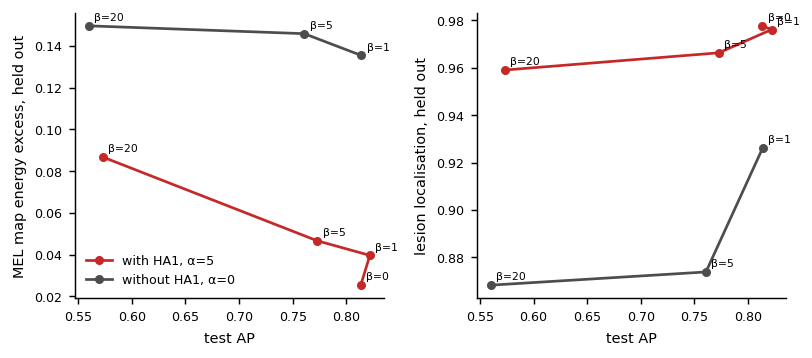

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(plotting.TEXTWIDTH, 2.8))
for a, c, lab in [(5.0, plotting.C_FOCUS, "with HA1, α=5"),
                  (0.0, plotting.C_CONTROL, "without HA1, α=0")]:
    g = FR[FR.alpha == a].groupby("beta")[["mel_on_mel", "lesion_auc"]].median()
    cl = FC[FC.alpha == a].groupby("beta").ap.mean()
    g = g.join(cl)
    for j, y in enumerate(["mel_on_mel", "lesion_auc"]):
        ax[j].plot(g.ap, g[y], "o-", color=c, label=lab, lw=1.5, ms=4)
        for b in g.index:
            ax[j].annotate(f"β={b:g}", (g.loc[b, "ap"], g.loc[b, y]),
                           xytext=(3, 3), textcoords="offset points", fontsize=6)
ax[0].set(xlabel="test AP", ylabel="MEL map energy excess, held out")
ax[1].set(xlabel="test AP", ylabel="lesion localisation, held out")
ax[0].legend(frameon=False)
fig.tight_layout()
plotting.save(fig, "f2_two_curves")
plt.show()

In [12]:
def energy_grid(v, T):
    v = cams.norm01(v)
    return float(v[T].sum() / (v.sum() + 1e-8) - T.mean())

FR["mel_whole_grid"] = np.nan
for (a, b), grp in FR.groupby(["alpha", "beta"]):
    for k in range(5):
        m = models.f2(a, b, k)
        for idx in grp.index:
            iid = FR.at[idx, "image_id"]
            if FOLD[iid] != k:
                continue
            mel, _ = cams.class_cams(m, data.to_tensor(data.native(EV.loc[iid].image_rel_path)))
            FR.at[idx, "mel_whole_grid"] = energy_grid(mel, HUM[iid] & LESION[iid])
        del m
FR.to_csv(TAB / "f2_full_grounding.csv", index=False)
print(FR.groupby(["alpha", "beta"])[["mel_on_mel", "mel_whole_grid", "lesion_auc"]]
      .median().round(3).to_string())
base = FR[(FR.alpha == 5) & (FR.beta == 0)].set_index("image_id")
for (a, b) in [(5.0, 1.0), (5.0, 5.0), (0.0, 1.0), (0.0, 5.0)]:
    s = FR[(FR.alpha == a) & (FR.beta == b)].set_index("image_id")
    r = metrics.paired(s.mel_whole_grid, base.mel_whole_grid)
    print(f"  alpha {a:g} beta {b:g} vs HA1 only, whole grid  {r['diff']:+.3f}  p {r['p']:.4f}")

            mel_on_mel  mel_whole_grid  lesion_auc
alpha beta                                        
0.0   1.0        0.135           0.528       0.926
      5.0        0.146           0.556       0.874
      20.0       0.150           0.591       0.868
5.0   0.0        0.025           0.350       0.978
      1.0        0.040           0.415       0.976
      5.0        0.047           0.449       0.966
      20.0       0.087           0.506       0.959
  alpha 5 beta 1 vs HA1 only, whole grid  +0.023  p 0.0000
  alpha 5 beta 5 vs HA1 only, whole grid  +0.070  p 0.0000
  alpha 0 beta 1 vs HA1 only, whole grid  +0.130  p 0.0000
  alpha 0 beta 5 vs HA1 only, whole grid  +0.180  p 0.0000
